In [1]:
import liana as li
# needed for visualization and toy data
import scanpy as sc

In [2]:
adata = sc.read_h5ad('../../../oscb/uploads/Mouse_brain_atlas_scanpy.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 14249 × 3000
    obs: 'label', 'sizeFactor', 'subclass', 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_from_cache', 'age_days', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'ccc_target', 'class', 'cluster', 'cluster_correlation', 'complexity_cg', 'confusion_score', 'core_intermediate_call', 'donor', 'driver_lines', 'eye_cond

In [4]:
adata.X.todense()

matrix([[   0.,    0.,    0., ...,    0.,  772.,   10.],
        [   0.,    0.,    0., ...,    0., 1193.,    0.],
        [   0.,    0.,    0., ...,    0., 1104.,    0.],
        ...,
        [   0.,    0.,    0., ...,    0.,   74.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,  248.,    0.]])

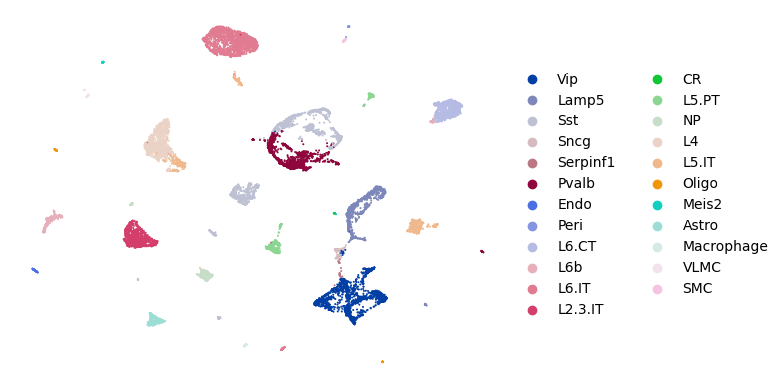

In [5]:
sc.pl.umap(adata, color='label', title='', frameon=False)

In [6]:
adata.raw == None

True

In [7]:
adata.raw = adata.copy()
adata.raw.X

<14249x3000 sparse matrix of type '<class 'numpy.float64'>'
	with 5699409 stored elements in Compressed Sparse Row format>

In [8]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [9]:
# import liana's rank_aggregate
from liana.mt import rank_aggregate

In [10]:
?rank_aggregate.__call__

Signature:
rank_aggregate.__call__(
    adata: 'an.AnnData | MuData',
    groupby: 'str',
    resource_name: 'str' = 'consensus',
    expr_prop: 'float' = 0.1,
    min_cells: 'int' = 5,
    groupby_pairs: 'Optional[DataFrame]' = None,
    base: 'float' = 2.718281828459045,
    aggregate_method: 'str' = 'rra',
    consensus_opts: 'Optional[list]' = None,
    return_all_lrs: 'bool' = False,
    key_added: 'str' = 'liana_res',
    use_raw: 'Optional[bool]' = True,
    layer: 'Optional[str]' = None,
    de_method: 'str' = 't-test',
    n_perms: 'int' = 1000,
    seed: 'int' = 1337,
    n_jobs: 'int' = 1,
    resource: 'Optional[DataFrame]' = None,
    interactions: 'Optional[list]' = None,
    mdata_kwargs: 'dict' = {},
    inplace: 'bool' = True,
    verbose: 'Optional[bool]' = False,
)
Docstring:
Get an aggregate of ligand-receptor scores from multiple methods.

Parameters
----------
adata
    Annotated data object.
groupby
    Key to be used for grouping.
resource_name
    Name of the r

In [11]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


In [12]:
# import all individual methods

from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean


In [13]:
# run cellphonedb
cellphonedb(adata,
            groupby='label', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            key_added='cellphonedb')

# by default, liana's output is saved in place:
adata.uns['cellphonedb'].head()

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 93.13it/s]


,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
5519,Vip,Vip,45083.566406,0.987269,Ramp2,Ramp2,3738.967285,1.000000,Vip,Endo,24411.267578,0.0
10955,Vip,Vip,45083.566406,0.987269,Ramp1,Ramp1,2655.571533,1.000000,Vip,CR,23869.568359,0.0
19895,Vip,Vip,45083.566406,0.987269,Gpr20,Gpr20,606.163452,0.818182,Vip,SMC,22844.865234,0.0
13060,Vip,Vip,45083.566406,0.987269,Ramp1,Ramp1,564.533203,0.999286,Vip,L4,22824.050781,0.0
17146,Vip,Vip,45083.566406,0.987269,Adrb2,Adrb2,515.843201,0.549020,Vip,Macrophage,22799.705078,0.0


In [14]:
singlecellsignalr(adata,
            groupby='label', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            key_added='singlecellsignalr')
adata.uns['singlecellsignalr'].head()

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features


,ligand,ligand_complex,ligand_means,ligand_props,mat_mean,receptor,receptor_complex,receptor_means,receptor_props,source,target,lrscore
5519,Vip,Vip,45083.566406,0.987269,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Vip,Endo,0.996298
10955,Vip,Vip,45083.566406,0.987269,48.235962,Ramp1,Ramp1,2655.571533,1.000000,Vip,CR,0.995611
5771,Vip,Vip,16811.925781,0.851852,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Serpinf1,Endo,0.993953
18134,Apoe,Apoe,26167.210938,1.000000,48.235962,Trem2,Trem2,2372.196045,0.941176,VLMC,Macrophage,0.993915
5702,Vip,Vip,16109.229492,0.840000,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Sncg,Endo,0.993823


In [15]:
connectome(adata,
            groupby='label', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            key_added='connectome')
adata.uns['connectome'].head()

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features


/opt/conda/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


,ligand,ligand_complex,ligand_means,ligand_props,ligand_zscores,receptor,receptor_complex,receptor_means,receptor_props,receptor_zscores,source,target,expr_prod,scaled_weight
5519,Vip,Vip,45083.566406,0.987269,2.165664,Ramp2,Ramp2,3738.967285,1.000000,10.341837,Vip,Endo,168565984.0,6.253750
10955,Vip,Vip,45083.566406,0.987269,2.165664,Ramp1,Ramp1,2655.571533,1.000000,7.833672,Vip,CR,119722632.0,4.999668
5771,Vip,Vip,16811.925781,0.851852,0.613086,Ramp2,Ramp2,3738.967285,1.000000,10.341837,Serpinf1,Endo,62859240.0,5.477461
18134,Apoe,Apoe,26167.210938,1.000000,6.990719,Trem2,Trem2,2372.196045,0.941176,12.644125,VLMC,Macrophage,62073756.0,9.817422
5702,Vip,Vip,16109.229492,0.840000,0.574496,Ramp2,Ramp2,3738.967285,1.000000,10.341837,Sncg,Endo,60231884.0,5.458167


In [16]:
natmi(adata,
            groupby='label', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            key_added='natmi')
adata.uns['natmi'].head()

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features


,ligand,ligand_complex,ligand_means,ligand_means_sums,ligand_props,receptor,receptor_complex,receptor_means,receptor_means_sums,receptor_props,source,target,expr_prod,spec_weight
5519,Vip,Vip,45083.566406,79155.820312,0.987269,Ramp2,Ramp2,3738.967285,4901.927246,1.000000,Vip,Endo,168565984.0,0.434430
10955,Vip,Vip,45083.566406,79155.820312,0.987269,Ramp1,Ramp1,2655.571533,7929.583984,1.000000,Vip,CR,119722632.0,0.190741
5771,Vip,Vip,16811.925781,79155.820312,0.851852,Ramp2,Ramp2,3738.967285,4901.927246,1.000000,Serpinf1,Endo,62859240.0,0.162002
18134,Apoe,Apoe,26167.210938,53288.851562,1.000000,Trem2,Trem2,2372.196045,2399.184326,0.941176,VLMC,Macrophage,62073756.0,0.485521
5702,Vip,Vip,16109.229492,79155.820312,0.840000,Ramp2,Ramp2,3738.967285,4901.927246,1.000000,Sncg,Endo,60231884.0,0.155230


In [17]:
logfc(adata,
            groupby='label', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            key_added='logfc')
adata.uns['logfc'].head()

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features
Assuming that counts were `natural` log-normalized!


/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:272: ImplicitModificationWarning: Setting element `.layers['normcounts']` of view, initializing view as actual.
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:360: RuntimeWarning: overflow encountered in power
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana

,ligand,ligand_complex,ligand_logfc,ligand_means,ligand_props,receptor,receptor_complex,receptor_logfc,receptor_means,receptor_props,source,target,lr_logfc
18066,Ccl12,Ccl12,inf,259.254944,0.568627,Ccr1,Ccr1,inf,228.156876,0.137255,Macrophage,Macrophage,inf
519,Plat,Plat,-inf,1.428571,0.142857,Itgam,Itgam,-inf,0.113426,0.104167,CR,Vip,-inf
11719,Adam17,Adam17,-inf,4.575999,0.288000,Notch1,Notch1,-inf,0.775735,0.139706,Sncg,L5.PT,-inf
11433,Vip,Vip,-inf,0.978022,0.329670,Ramp2,Ramp2,-inf,11.000001,0.142857,Oligo,CR,-inf
11439,Crh,Crh,-inf,0.186813,0.120879,Ramp2,Ramp2,-inf,11.000001,0.142857,Oligo,CR,-inf


In [18]:
cellchat(adata,
            groupby='label', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            key_added='cellchat')
adata.uns['cellchat'].head()

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features


/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_get_mean_perms.py:44: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:41<00:00,  9.90it/s]


,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
5519,Vip,Vip,0.987269,0.102359,411165.0,Ramp2,Ramp2,1.000000,0.008597,Vip,Endo,0.001757,0.0
10955,Vip,Vip,0.987269,0.102359,411165.0,Ramp1,Ramp1,1.000000,0.005267,Vip,CR,0.001077,0.0
18134,Apoe,Apoe,1.000000,0.058266,411165.0,Trem2,Trem2,0.941176,0.004790,VLMC,Macrophage,0.000558,0.0
5942,Bsg,Bsg,1.000000,0.087308,411165.0,Slc16a1,Slc16a1,0.851064,0.002367,Endo,Endo,0.000413,0.0
6781,Apoe,Apoe,1.000000,0.058266,411165.0,Lsr,Lsr,0.936170,0.003081,VLMC,Endo,0.000359,0.0


In [19]:
geometric_mean(adata,
            groupby='label', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, 
            key_added='geometric_mean')
adata.uns['geometric_mean'].head()

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 92.74it/s]


,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_gmeans,gmean_pvals
5519,Vip,Vip,45083.566406,0.987269,Ramp2,Ramp2,3738.967285,1.000000,Vip,Endo,12983.289062,0.0
10955,Vip,Vip,45083.566406,0.987269,Ramp1,Ramp1,2655.571533,1.000000,Vip,CR,10941.788086,0.0
5771,Vip,Vip,16811.925781,0.851852,Ramp2,Ramp2,3738.967285,1.000000,Serpinf1,Endo,7928.385742,0.0
18134,Apoe,Apoe,26167.210938,1.000000,Trem2,Trem2,2372.196045,0.941176,VLMC,Macrophage,7878.691406,0.0
5702,Vip,Vip,16109.229492,0.840000,Ramp2,Ramp2,3738.967285,1.000000,Sncg,Endo,7760.916992,0.0


In [93]:
adata.uns['geometric_mean'][9100:9150]

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_gmeans,gmean_pvals,score
10410,Vegfa,Vegfa,112.477158,0.972326,Itgb1,Itgb1,35.474594,0.670061,Pvalb,L2.3.IT,63.167088,0.168,0.000000
6495,Cxcl12,Cxcl12,17.257956,0.219318,Ackr3,Ackr3,231.202148,0.617021,L5.IT,Endo,63.167061,0.003,63.167061
15819,Fgf1,Fgf1,102.540764,0.508152,Fgfr2,Fgfr2,38.911110,0.155556,Astro,Meis2,63.166245,0.000,63.166245
4212,Vegfa,Vegfa,54.005527,0.660221,Egfr,Egfr,73.851845,0.592593,NP,Serpinf1,63.153835,0.016,63.153835
19384,Vcl,Vcl,22.205690,0.573864,Itgb5,Itgb5,179.507462,0.567164,L5.IT,VLMC,63.135471,0.007,63.135471
6627,Adam17,Adam17,36.491863,0.187500,Rhbdf2,Rhbdf2,109.031914,0.372340,Astro,Endo,63.077579,0.000,63.077579
7793,Gpc3,Gpc3,30.133335,0.177778,Flt1,Flt1,132.031250,0.281250,Meis2,Peri,63.075680,0.002,63.075680
8030,Pros1,Pros1,54.490906,0.127273,Mertk,Mertk,72.968750,0.156250,SMC,Peri,63.056580,0.008,63.056580
3676,Vegfa,Vegfa,53.833336,0.736185,Egfr,Egfr,73.851845,0.592593,Lamp5,Serpinf1,63.053101,0.020,63.053101
6320,Alcam,Alcam,7.992643,0.240809,Nrp1,Nrp1,497.287262,0.808511,L5.PT,Endo,63.044739,1.000,0.000000


In [20]:
'geometric_mean' in adata.uns.keys()

True

In [80]:
# Run rank_aggregate
li.mt.rank_aggregate(adata, 
                     groupby='subclass',
                     resource_name='mouseconsensus',
                     expr_prop=0.1,
                     aggregate_method ="mean",
                     verbose=True)

Using resource `mouseconsensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Make sure that normalized counts are passed!
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.69 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14249 samples and 331 features
Assuming that counts were `natural` log-normalized!


/opt/conda/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:360: RuntimeWarning: overflow encountered in power
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:354: RuntimeWarning: invalid value encountered in subtract
/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:

Running CellPhoneDB


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 98.86it/s]


Running Connectome
Running log2FC


/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce


Running NATMI
Running SingleCellSignalR


In [88]:
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
19478,Vip,Endo,Vip,Ramp2,24411.267578,0.0,168565984.0,6.253750,NaN,0.434430,0.996298,NaN,0.333366
19422,Vip,CR,Vip,Ramp1,23869.568359,0.0,119722632.0,4.999668,NaN,0.190741,0.995611,NaN,0.333383
20024,Vip,SMC,Vip,Gpr20,22844.865234,0.0,27328010.0,6.462730,NaN,0.554798,0.990857,NaN,0.333399
19541,Vip,L4,Vip,Ramp1,22824.050781,0.0,25451170.0,1.596069,NaN,0.040548,0.990529,NaN,0.333416
19787,Vip,Macrophage,Vip,Adrb2,22799.705078,0.0,23256052.0,5.590290,NaN,0.478705,0.990097,NaN,0.333432


In [89]:
adata.uns['liana_res']

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
19478,Vip,Endo,Vip,Ramp2,24411.267578,0.000,1.685660e+08,6.253750,NaN,4.344304e-01,0.996298,NaN,0.333366
19422,Vip,CR,Vip,Ramp1,23869.568359,0.000,1.197226e+08,4.999668,NaN,1.907406e-01,0.995611,NaN,0.333383
20024,Vip,SMC,Vip,Gpr20,22844.865234,0.000,2.732801e+07,6.462730,NaN,5.547978e-01,0.990857,NaN,0.333399
19541,Vip,L4,Vip,Ramp1,22824.050781,0.000,2.545117e+07,1.596069,NaN,4.054847e-02,0.990529,NaN,0.333416
19787,Vip,Macrophage,Vip,Adrb2,22799.705078,0.000,2.325605e+07,5.590290,NaN,4.787053e-01,0.990097,NaN,0.333432
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12206,Oligo,Vip,Selplg,Itgam,0.139131,0.991,1.869657e-02,-0.042824,-inf,4.728912e-09,0.002827,NaN,0.666617
11924,Oligo,Pvalb,Selplg,Itgam,0.138887,0.977,1.861636e-02,-0.042828,-inf,4.708625e-09,0.002821,NaN,0.666634
11977,Oligo,SMC,Selplg,Itgam,0.136963,0.430,1.798202e-02,-0.042859,-inf,4.548181e-09,0.002772,NaN,0.666650
11565,Oligo,L5.PT,Selplg,Itgam,0.135726,0.839,1.757435e-02,-0.042880,-inf,4.445069e-09,0.002741,NaN,0.666667


# Evaluation

In [23]:
from typing import Union

import anndata
import collections
import numpy as np
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve

In [24]:
adata.uns["ccc_target"]

,source,target,response
0,CR,Astro,0
1,Endo,Astro,1
2,L2.3.IT,Astro,0
3,L4,Astro,0
4,L5.IT,Astro,0
...,...,...,...
501,Serpinf1,VLMC,0
502,SMC,VLMC,0
503,Sncg,VLMC,0
504,Sst,VLMC,0


In [82]:
# Helper function to filter according to permutation p-values
def _p_filt(x, y):
    if x <= 0.05:
        return y
    else:
        return 0

def aggregate_method_scores(adata, how, ccc_pred="liana_res", score="score"):
    merge_keys = list(adata.uns["merge_keys"])
    return (
        adata.uns[ccc_pred]
        .groupby(merge_keys)
        .agg(score=(score, how))
        .reset_index()
    )

In [84]:
adata.uns["ccc_pred"] = aggregate_method_scores(adata.copy(), how="max", ccc_pred='liana_res', score="lrscore")
adata

AnnData object with n_obs × n_vars = 14249 × 3000
    obs: 'label', 'sizeFactor', 'subclass', 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden', 'louvain'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_from_cache', 'age_days', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'ccc_target', 'class', 'cluster', 'cluster_correlation', 'complexity_cg', 'confusion_score', 'core_intermediate_call', 'donor', 'driver_lines', 'eye_cond

In [86]:
adata.uns["geometric_mean"]["score"] = adata.uns["geometric_mean"].apply(
            lambda x: _p_filt(x.gmean_pvals, x["lr_gmeans"]), axis=1)

In [87]:
adata.uns["geometric_mean"]

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_gmeans,gmean_pvals,score
5519,Vip,Vip,45083.566406,0.987269,Ramp2,Ramp2,3738.967285,1.000000,Vip,Endo,12983.289062,0.000,12983.289062
10955,Vip,Vip,45083.566406,0.987269,Ramp1,Ramp1,2655.571533,1.000000,Vip,CR,10941.788086,0.000,10941.788086
5771,Vip,Vip,16811.925781,0.851852,Ramp2,Ramp2,3738.967285,1.000000,Serpinf1,Endo,7928.385742,0.000,7928.385742
18134,Apoe,Apoe,26167.210938,1.000000,Trem2,Trem2,2372.196045,0.941176,VLMC,Macrophage,7878.691406,0.000,7878.691406
5702,Vip,Vip,16109.229492,0.840000,Ramp2,Ramp2,3738.967285,1.000000,Sncg,Endo,7760.916992,0.000,7760.916992
...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,Selplg,Selplg,0.164835,0.142857,Itgam,Itgam,0.113426,0.104167,Oligo,Vip,0.136735,0.712,0.000000
5220,Selplg,Selplg,0.164835,0.142857,Itgam,Itgam,0.112939,0.103216,Oligo,Pvalb,0.136442,0.685,0.000000
20926,Selplg,Selplg,0.164835,0.142857,Itgam,Itgam,0.109091,0.109091,Oligo,SMC,0.134097,0.382,0.000000
12138,Selplg,Selplg,0.164835,0.142857,Itgam,Itgam,0.106618,0.101103,Oligo,L5.PT,0.132568,0.590,0.000000


In [42]:
# Join predictions to target
def join_truth_and_pred(adata, ccc_pred="liana_res", ccc_target="ccc_target", score="lrscore"):
    merge_keys = list(adata.uns["merge_keys"])
    gt = adata.uns[ccc_target].merge(adata.uns[ccc_pred], on=merge_keys, how="left")

    gt.loc[gt["response"].isna(), "response"] = 0
    gt.loc[gt[score].isna(), score] = np.nanmin(gt[score]) - np.finfo(float).eps

    return gt

In [65]:
gt = join_truth_and_pred(adata, ccc_pred="cellphonedb", ccc_target="ccc_target", score="cellphone_pvals")
gt

,source,target,response,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,lr_means,cellphone_pvals
0,CR,Astro,0,Spp1,Spp1,23.285715,0.142857,S1pr1,S1pr1,2559.961182,1.000000,1291.623413,0.002
1,CR,Astro,0,Bdnf,Bdnf,0.714286,0.285714,Ntrk2,Ntrk2,1687.761353,0.991848,844.237793,0.003
2,CR,Astro,0,Mdk,Mdk,37.571430,0.285714,Ptprz1,Ptprz1,1348.461670,1.000000,693.016541,0.000
3,CR,Astro,0,Ptn,Ptn,7.428572,0.428571,Ptprz1,Ptprz1,1348.461670,1.000000,677.945129,0.100
4,CR,Astro,0,Bsg,Bsg,1178.428589,1.000000,Slc16a1,Slc16a1,102.540771,0.301630,640.484680,0.846
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19298,Vip,VLMC,0,Adm,Adm,14.443290,0.147569,Ackr3,Ackr3,25.940296,0.134328,20.191793,0.151
19299,Vip,VLMC,0,Lama5,Lama5,7.593173,0.134838,Bcam,Bcam,25.999998,0.208955,16.796585,0.086
19300,Vip,VLMC,0,Inhba,Inhba,5.337387,0.137153,Eng,Eng,28.104477,0.343284,16.720932,0.234
19301,Vip,VLMC,0,Adam17,Adam17,7.751159,0.141204,Notch1,Notch1,8.059701,0.194030,7.905430,0.434


In [80]:
adata.uns['singlecellsignalr']

,ligand,ligand_complex,ligand_means,ligand_props,mat_mean,receptor,receptor_complex,receptor_means,receptor_props,source,target,lrscore
5519,Vip,Vip,45083.566406,0.987269,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Vip,Endo,0.996298
10955,Vip,Vip,45083.566406,0.987269,48.235962,Ramp1,Ramp1,2655.571533,1.000000,Vip,CR,0.995611
5771,Vip,Vip,16811.925781,0.851852,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Serpinf1,Endo,0.993953
18134,Apoe,Apoe,26167.210938,1.000000,48.235962,Trem2,Trem2,2372.196045,0.941176,VLMC,Macrophage,0.993915
5702,Vip,Vip,16109.229492,0.840000,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Sncg,Endo,0.993823
...,...,...,...,...,...,...,...,...,...,...,...,...
655,Selplg,Selplg,0.164835,0.142857,48.235962,Itgam,Itgam,0.113426,0.104167,Oligo,Vip,0.002827
5220,Selplg,Selplg,0.164835,0.142857,48.235962,Itgam,Itgam,0.112939,0.103216,Oligo,Pvalb,0.002821
20926,Selplg,Selplg,0.164835,0.142857,48.235962,Itgam,Itgam,0.109091,0.109091,Oligo,SMC,0.002772
12138,Selplg,Selplg,0.164835,0.142857,48.235962,Itgam,Itgam,0.106618,0.101103,Oligo,L5.PT,0.002741


In [71]:
'lrscore' not in gt.columns

False

In [57]:
# Cell Cell Communication
def ccc_metrics(adata, ccc_pred="ccc_pred", ccc_target="ccc_target", score="lrscore", top_prop=0.05):
    # Precision-recall AUC
    gt = join_truth_and_pred(adata, ccc_pred, ccc_target, score)
    precision, recall, _ = precision_recall_curve(
        gt["response"], gt[score], pos_label=1
    )

    auc_score = auc(recall, precision)

    # Odds Ratio
    gt = gt.sort_values(score, ascending=False)
    top_n = int(adata.uns[ccc_target].shape[0] * top_prop)

    # assign the top rank interactions to 1
    a = np.zeros(len(gt[score]))
    a[0:top_n] = 1
    gt.loc[:, ["top_n"]] = a

    top = gt[gt["top_n"] == 1]
    tp = np.sum(top.response == 1)
    fp = np.sum(top.response == 0)

    bot = gt[gt["top_n"] == 0]
    fn = np.sum(bot.response == 1)
    tn = np.sum(bot.response == 0)

    numerator = tp * tn
    denominator = fp * fn
    if denominator == 0:
        if numerator == 0:
            # undefined
            oddsratio_score = np.nan
        else:
            # perfect score
            oddsratio_score = np.inf
    else:
        oddsratio_score = numerator / denominator
        oddsratio_score = _sigmoid_transform(oddsratio_score)

    return float('{:.4f}'.format(auc_score)), float('{:.4f}'.format(oddsratio_score))

In [58]:
def _sigmoid_transform(x):
    return 1 - 1 / (1 + x / 2)

In [61]:
auc_score=0
oddsratio=0
auc_score, oddsratio = ccc_metrics(adata, ccc_pred="liana_res", ccc_target="ccc_target", score="lrscore", top_prop=0.05)
print(auc_score, " ", oddsratio)

0.0801   0.606


/tmp/ipykernel_1770/4009854828.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.002707032486796157' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.


In [29]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [62]:
adata.uns['singlecellsignalr'].head()

,ligand,ligand_complex,ligand_means,ligand_props,mat_mean,receptor,receptor_complex,receptor_means,receptor_props,source,target,lrscore
5519,Vip,Vip,45083.566406,0.987269,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Vip,Endo,0.996298
10955,Vip,Vip,45083.566406,0.987269,48.235962,Ramp1,Ramp1,2655.571533,1.000000,Vip,CR,0.995611
5771,Vip,Vip,16811.925781,0.851852,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Serpinf1,Endo,0.993953
18134,Apoe,Apoe,26167.210938,1.000000,48.235962,Trem2,Trem2,2372.196045,0.941176,VLMC,Macrophage,0.993915
5702,Vip,Vip,16109.229492,0.840000,48.235962,Ramp2,Ramp2,3738.967285,1.000000,Sncg,Endo,0.993823


In [70]:
auc_score, oddsratio_score = ccc_metrics(adata, ccc_pred="singlecellsignalr", ccc_target="ccc_target", score='lrscore')
print(auc_score, " ", oddsratio_score)

0.0801   0.606


/tmp/ipykernel_1770/4009854828.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.002707032486796157' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.


In [68]:
adata.uns['cellchat'].head()

,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
5519,Vip,Vip,0.987269,0.102359,411165.0,Ramp2,Ramp2,1.000000,0.008597,Vip,Endo,0.001757,0.0
10955,Vip,Vip,0.987269,0.102359,411165.0,Ramp1,Ramp1,1.000000,0.005267,Vip,CR,0.001077,0.0
18134,Apoe,Apoe,1.000000,0.058266,411165.0,Trem2,Trem2,0.941176,0.004790,VLMC,Macrophage,0.000558,0.0
5942,Bsg,Bsg,1.000000,0.087308,411165.0,Slc16a1,Slc16a1,0.851064,0.002367,Endo,Endo,0.000413,0.0
6781,Apoe,Apoe,1.000000,0.058266,411165.0,Lsr,Lsr,0.936170,0.003081,VLMC,Endo,0.000359,0.0


In [71]:
auc_score, oddsratio_score = ccc_metrics(adata, ccc_pred="cellchat", ccc_target="ccc_target", score='cellchat_pvals')
print(auc_score, " ", oddsratio_score)

0.325   0.0


In [48]:
adata.uns['cellphonedb'].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
5519,Vip,Vip,45083.566406,0.987269,Ramp2,Ramp2,3738.967285,1.000000,Vip,Endo,24411.267578,0.0
10955,Vip,Vip,45083.566406,0.987269,Ramp1,Ramp1,2655.571533,1.000000,Vip,CR,23869.568359,0.0
19895,Vip,Vip,45083.566406,0.987269,Gpr20,Gpr20,606.163452,0.818182,Vip,SMC,22844.865234,0.0
13060,Vip,Vip,45083.566406,0.987269,Ramp1,Ramp1,564.533203,0.999286,Vip,L4,22824.050781,0.0
17146,Vip,Vip,45083.566406,0.987269,Adrb2,Adrb2,515.843201,0.549020,Vip,Macrophage,22799.705078,0.0


In [72]:
auc_score, oddsratio_score = ccc_metrics(adata, ccc_pred="cellphonedb", ccc_target="ccc_target", score='cellphone_pvals')
print(auc_score, " ", oddsratio_score)

0.1447   0.0


In [67]:
adata.uns['connectome'].head()

,ligand,ligand_complex,ligand_means,ligand_props,ligand_zscores,receptor,receptor_complex,receptor_means,receptor_props,receptor_zscores,source,target,expr_prod,scaled_weight
5519,Vip,Vip,45083.566406,0.987269,2.165664,Ramp2,Ramp2,3738.967285,1.000000,10.341837,Vip,Endo,168565984.0,6.253750
10955,Vip,Vip,45083.566406,0.987269,2.165664,Ramp1,Ramp1,2655.571533,1.000000,7.833672,Vip,CR,119722632.0,4.999668
5771,Vip,Vip,16811.925781,0.851852,0.613086,Ramp2,Ramp2,3738.967285,1.000000,10.341837,Serpinf1,Endo,62859240.0,5.477461
18134,Apoe,Apoe,26167.210938,1.000000,6.990719,Trem2,Trem2,2372.196045,0.941176,12.644125,VLMC,Macrophage,62073756.0,9.817422
5702,Vip,Vip,16109.229492,0.840000,0.574496,Ramp2,Ramp2,3738.967285,1.000000,10.341837,Sncg,Endo,60231884.0,5.458167


In [73]:
auc_score, oddsratio_score = ccc_metrics(adata, ccc_pred="connectome", ccc_target="ccc_target", score='scaled_weight')
print(auc_score, " ", oddsratio_score)

0.0907   0.7187


In [56]:
np.finfo(float).eps

2.220446049250313e-16

In [35]:
adata.uns['natmi'].head()

,ligand,ligand_complex,ligand_means,ligand_means_sums,ligand_props,receptor,receptor_complex,receptor_means,receptor_means_sums,receptor_props,source,target,expr_prod,spec_weight
5519,Vip,Vip,45083.566406,79155.820312,0.987269,Ramp2,Ramp2,3738.967285,4901.927246,1.000000,Vip,Endo,168565984.0,0.434430
10955,Vip,Vip,45083.566406,79155.820312,0.987269,Ramp1,Ramp1,2655.571533,7929.583984,1.000000,Vip,CR,119722632.0,0.190741
5771,Vip,Vip,16811.925781,79155.820312,0.851852,Ramp2,Ramp2,3738.967285,4901.927246,1.000000,Serpinf1,Endo,62859240.0,0.162002
18134,Apoe,Apoe,26167.210938,53288.851562,1.000000,Trem2,Trem2,2372.196045,2399.184326,0.941176,VLMC,Macrophage,62073756.0,0.485521
5702,Vip,Vip,16109.229492,79155.820312,0.840000,Ramp2,Ramp2,3738.967285,4901.927246,1.000000,Sncg,Endo,60231884.0,0.155230


In [74]:
auc_score, oddsratio_score = ccc_metrics(adata, ccc_pred="natmi", ccc_target="ccc_target", score='spec_weight')
print(auc_score, " ", oddsratio_score)

0.1039   0.606


In [75]:
adata.uns['logfc']

,ligand,ligand_complex,ligand_logfc,ligand_means,ligand_props,receptor,receptor_complex,receptor_logfc,receptor_means,receptor_props,source,target,lr_logfc
18066,Ccl12,Ccl12,inf,259.254944,0.568627,Ccr1,Ccr1,inf,228.156876,0.137255,Macrophage,Macrophage,inf
519,Plat,Plat,-inf,1.428571,0.142857,Itgam,Itgam,-inf,0.113426,0.104167,CR,Vip,-inf
11719,Adam17,Adam17,-inf,4.575999,0.288000,Notch1,Notch1,-inf,0.775735,0.139706,Sncg,L5.PT,-inf
11433,Vip,Vip,-inf,0.978022,0.329670,Ramp2,Ramp2,-inf,11.000001,0.142857,Oligo,CR,-inf
11439,Crh,Crh,-inf,0.186813,0.120879,Ramp2,Ramp2,-inf,11.000001,0.142857,Oligo,CR,-inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21349,Angptl4,Angptl4,NaN,32.472725,0.127273,Sdc4,Sdc4,NaN,108.545448,0.636364,SMC,SMC,NaN
21350,Ptn,Ptn,NaN,60.927277,0.363636,Sdc4,Sdc4,NaN,108.545448,0.636364,SMC,SMC,NaN
21351,Sparc,Sparc,NaN,2320.072998,1.000000,Eng,Eng,NaN,25.181816,0.254545,SMC,SMC,NaN
21352,Gpc3,Gpc3,NaN,88.309090,0.381818,Flt1,Flt1,-inf,2.963636,0.109091,SMC,SMC,NaN


In [76]:
adata.uns['logfc']['lr_logfc'] = adata.uns['logfc']['lr_logfc'].replace([-np.inf], 0)
adata.uns['logfc']['lr_logfc'] = adata.uns['logfc']['lr_logfc'].replace([np.inf], 1)
adata.uns['logfc']

,ligand,ligand_complex,ligand_logfc,ligand_means,ligand_props,receptor,receptor_complex,receptor_logfc,receptor_means,receptor_props,source,target,lr_logfc
18066,Ccl12,Ccl12,inf,259.254944,0.568627,Ccr1,Ccr1,inf,228.156876,0.137255,Macrophage,Macrophage,1.0
519,Plat,Plat,-inf,1.428571,0.142857,Itgam,Itgam,-inf,0.113426,0.104167,CR,Vip,0.0
11719,Adam17,Adam17,-inf,4.575999,0.288000,Notch1,Notch1,-inf,0.775735,0.139706,Sncg,L5.PT,0.0
11433,Vip,Vip,-inf,0.978022,0.329670,Ramp2,Ramp2,-inf,11.000001,0.142857,Oligo,CR,0.0
11439,Crh,Crh,-inf,0.186813,0.120879,Ramp2,Ramp2,-inf,11.000001,0.142857,Oligo,CR,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21349,Angptl4,Angptl4,NaN,32.472725,0.127273,Sdc4,Sdc4,NaN,108.545448,0.636364,SMC,SMC,NaN
21350,Ptn,Ptn,NaN,60.927277,0.363636,Sdc4,Sdc4,NaN,108.545448,0.636364,SMC,SMC,NaN
21351,Sparc,Sparc,NaN,2320.072998,1.000000,Eng,Eng,NaN,25.181816,0.254545,SMC,SMC,NaN
21352,Gpc3,Gpc3,NaN,88.309090,0.381818,Flt1,Flt1,-inf,2.963636,0.109091,SMC,SMC,NaN


In [77]:
auc_score, oddsratio_score = ccc_metrics(adata, ccc_pred="logfc", ccc_target="ccc_target", score='lr_logfc')
print(auc_score, " ", oddsratio_score)

0.057   0.4121


In [39]:
adata.uns['geometric_mean'].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_gmeans,gmean_pvals
5519,Vip,Vip,45083.566406,0.987269,Ramp2,Ramp2,3738.967285,1.000000,Vip,Endo,12983.289062,0.0
10955,Vip,Vip,45083.566406,0.987269,Ramp1,Ramp1,2655.571533,1.000000,Vip,CR,10941.788086,0.0
5771,Vip,Vip,16811.925781,0.851852,Ramp2,Ramp2,3738.967285,1.000000,Serpinf1,Endo,7928.385742,0.0
18134,Apoe,Apoe,26167.210938,1.000000,Trem2,Trem2,2372.196045,0.941176,VLMC,Macrophage,7878.691406,0.0
5702,Vip,Vip,16109.229492,0.840000,Ramp2,Ramp2,3738.967285,1.000000,Sncg,Endo,7760.916992,0.0


In [55]:
auc_score1, oddsratio_score1 = ccc_metrics(adata, ccc_pred="geometric_mean", ccc_target="ccc_target", score='lr_gmeans')
print(auc_score1, " ", oddsratio_score1)

0.0801   0.606


/tmp/ipykernel_1770/4009854828.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.13093073666095711' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.


In [54]:
oddsratio_score

0.606

In [41]:
adata.obs.subclass

F1S4_160108_001_A01      Vip
F1S4_160108_001_B01    Lamp5
F1S4_160108_001_C01    Lamp5
F1S4_160108_001_D01      Vip
F1S4_160108_001_E01    Lamp5
                       ...  
FYS4_171004_104_C01    L5.PT
FYS4_171004_104_D01      Sst
FYS4_171004_104_F01    L5.PT
FYS4_171004_104_G01      Sst
FYS4_171004_104_H01    Pvalb
Name: subclass, Length: 14249, dtype: category
Categories (23, object): ['Vip', 'Lamp5', 'Sst', 'Sncg', ..., 'Astro', 'Macrophage', 'VLMC', 'SMC']

In [69]:
adata.uns['liana_res'].lrscore

225468    0.996464
225117    0.995808
232628    0.991265
226537    0.990952
230182    0.990538
            ...   
75068     0.325162
75070     0.332730
75071     0.343057
114698    0.250318
235365    0.265766
Name: lrscore, Length: 235366, dtype: float32

In [16]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


In [22]:
methods = [logfc, geometric_mean]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [23]:
new_rank_aggregate(adata,
                   groupby='bulk_labels',
                   expr_prop=0.1, 
                   verbose=True,
                   # Note that with this option, we don't perform permutations
                   # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
                   n_perms=None,
                   use_raw=True,
                   )

Using resource `consensus`.
Using `.raw`!
/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/opt/conda/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!


/opt/conda/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:272: ImplicitModificationWarning: Setting element `.layers['normcounts']` of view, initializing view as actual.


Running log2FC
Running Geometric Mean


In [24]:
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_logfc,lr_gmeans,magnitude_rank
110,CD14+ Monocyte,CD56+ NK,TIMP1,CD63,1.435273,2.126363,0.000776
109,CD14+ Monocyte,CD56+ NK,S100A9,ITGB2,1.069681,2.048953,0.001553
20,CD14+ Monocyte,CD14+ Monocyte,S100A9,ITGB2,1.069747,1.979752,0.002329
838,CD56+ NK,CD56+ NK,SPON2,ITGB2,1.860055,1.926317,0.003106
782,CD56+ NK,CD14+ Monocyte,SPON2,ITGB2,1.860121,1.861258,0.003882
